In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data\\cleaned_facebook_ads.csv")

In [3]:
df.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,impressions,clicks,spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


# Univariate analysis

# Age distribution

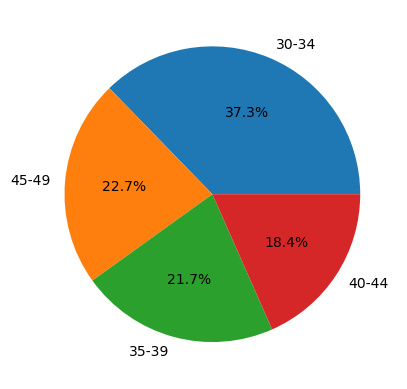

In [4]:
plt.pie(df['age'].value_counts(), labels=df['age'].value_counts().index, autopct='%1.1f%%')
plt.show()

# Gender distribution

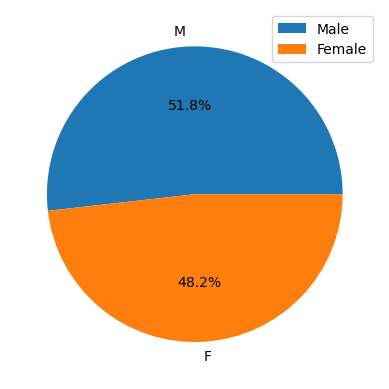

In [5]:
plt.pie(df['gender'].value_counts(), labels=df['gender'].value_counts().index, autopct = '%1.1f%%')
plt.legend(['Male','Female'])
plt.show()

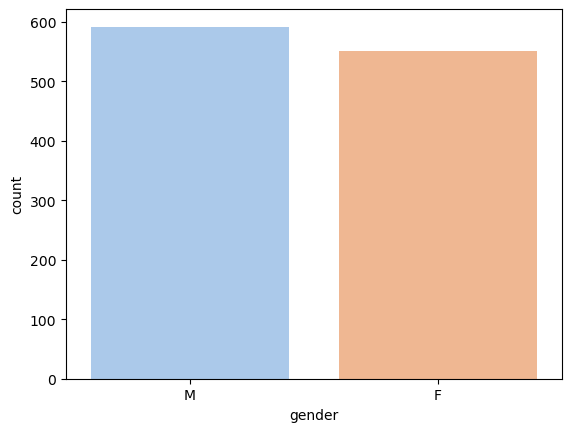

In [6]:
sns.countplot(x='gender', data=df, palette='pastel')
plt.show()

# Interest distribution

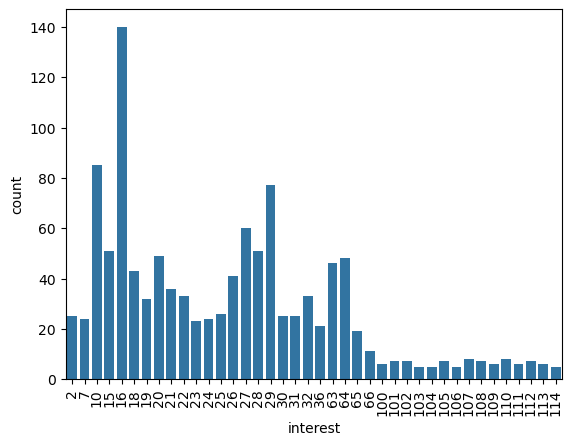

In [7]:
sns.countplot(x='interest', data=df)
plt.xticks(rotation=90)
plt.show()

# Insights

As you see on the above chart 16 interest reach more than others and after that 10, 29 have more interest these are the channels like 15 introduce for fitness, health as well as all are code of channels

# Impressions Distribution

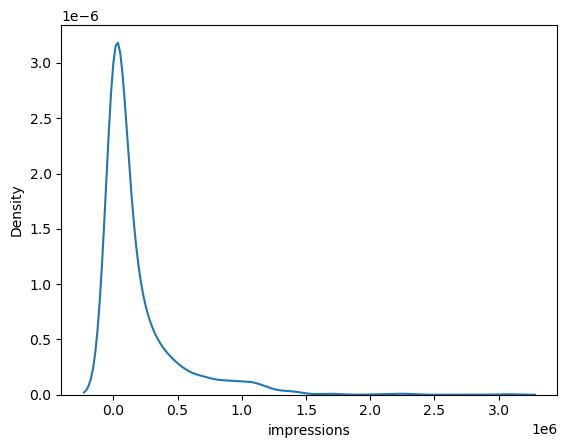

In [8]:
sns.kdeplot(x='impressions', data=df)
plt.show()

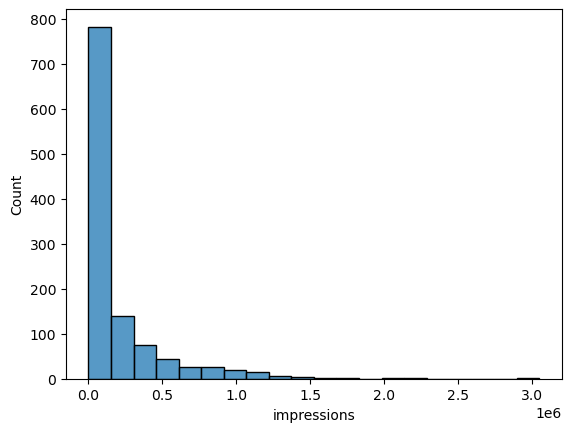

In [9]:
sns.histplot(x='impressions', data=df, bins=20)
plt.show()

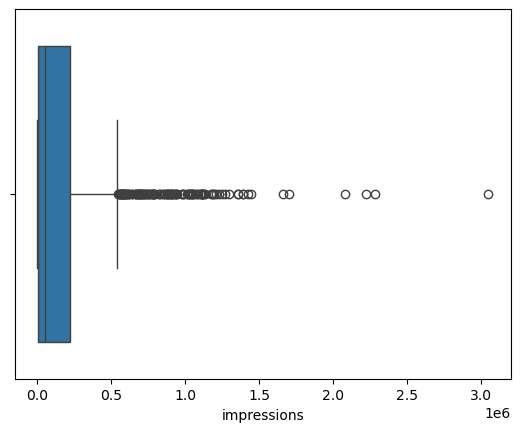

In [10]:
sns.boxplot(x='impressions', data=df)
plt.show()

In [11]:
Q1_impre, Q3_impre = df['impressions'].quantile([0.05,0.95])

In [12]:
print(Q1_impre, Q3_impre)

741.2 894449.3999999993


In [13]:
(df['impressions'] > Q3_impre).sum()

58

In [14]:
(df['impressions'] < Q1_impre).sum()

58

In [15]:
IQR_impre = Q3_impre - Q1_impre
IQR_impre

893708.1999999994

# Outliers detect on impressions

There are outliers detect on impressions if we take range 5% to 95% after that there is same number of outliers detected is 58

# Click distribution

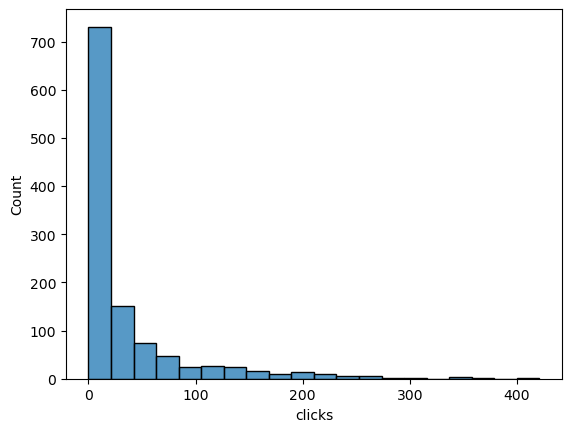

In [16]:
sns.histplot(x='clicks', data=df, bins=20)
plt.show()

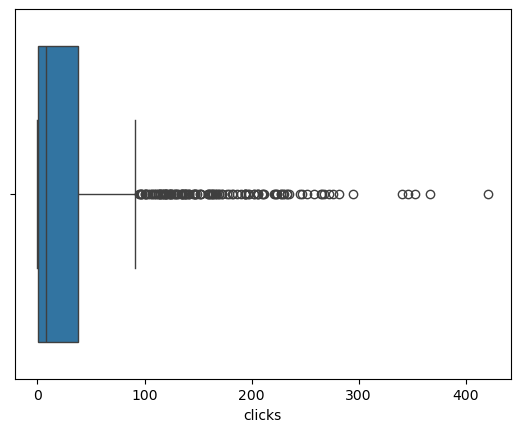

In [17]:
sns.boxplot(x='clicks', data=df)
plt.show()

In [18]:
Q1_clicks, Q3_clicks = df['clicks'].quantile([0.05,0.95])

In [19]:
print(Q1_clicks, Q3_clicks)

0.0 161.89999999999986


In [20]:
(df['clicks'] < Q1_clicks).sum()

0

In [21]:
(df['clicks'] > Q3_clicks).sum()

58

In [22]:
IQR_clicks = Q3_clicks - Q1_clicks
IQR_clicks

161.89999999999986

# Outliers on clicks 

There is also outliers detected but after 95% 

# Spent Distribution

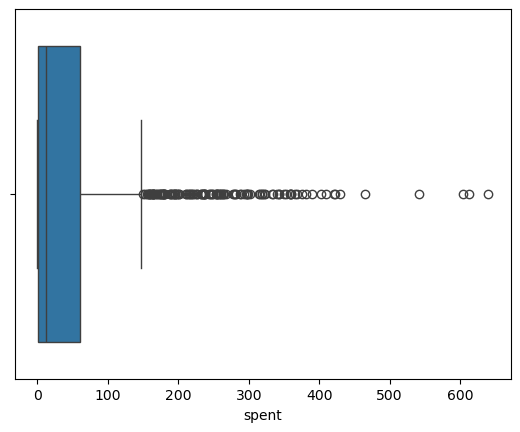

In [23]:
sns.boxplot(x='spent', data=df)
plt.show()

In [24]:
Q1_spent, Q3_spent = df['spent'].quantile([0.05,0.95])

In [25]:
print(Q1_spent, Q3_spent)

0.0 248.50800034999983


In [26]:
(df['spent'] < Q1_spent).sum()

0

In [27]:
(df['spent'] > Q3_spent).sum()

58

# Total Conversion

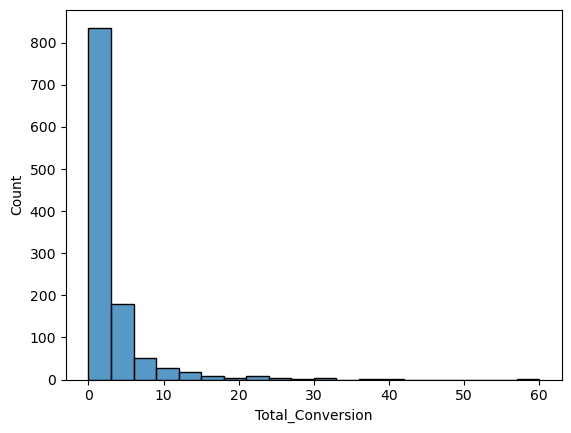

In [28]:
sns.histplot(x='Total_Conversion', data=df, bins=20)
plt.show()

# Approved Conversion

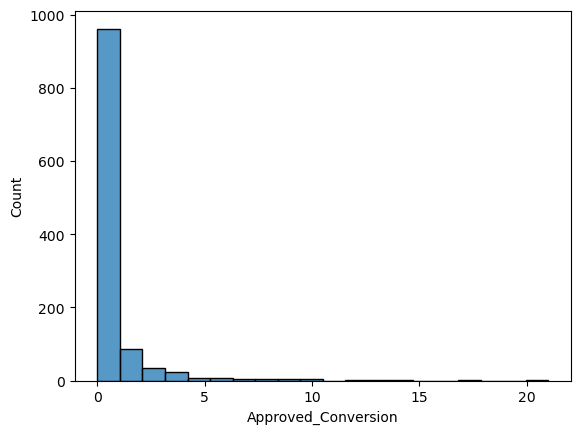

In [29]:
sns.histplot(x='Approved_Conversion', data=df, bins=20)
plt.show()

# Bivariate Analysis

## Age VS Clicks

which age group get more clicks ?

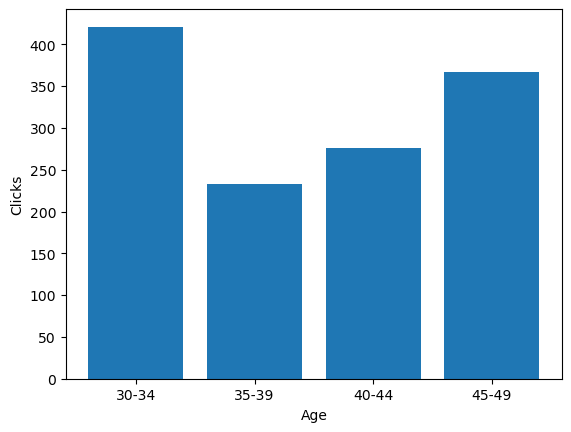

In [30]:
plt.bar(df['age'], df['clicks'])
plt.xlabel('Age')
plt.ylabel('Clicks')
plt.show()

30-34 and 45-49 get more clicks

# Age VS Spent
which age group receives the highest ad spend ?

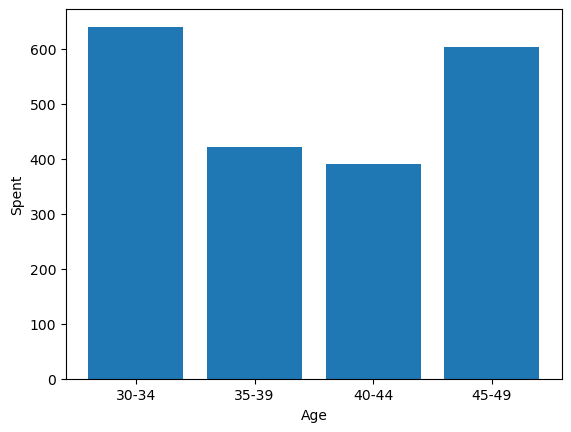

In [31]:
plt.bar(df['age'], df['spent'])
plt.xlabel('Age')
plt.ylabel('Spent')
plt.show()

# Insights 
Here is also 30-34 and 45-49 age group spend more than others

# Age VS Approved conversion
Which age group purchases the most?

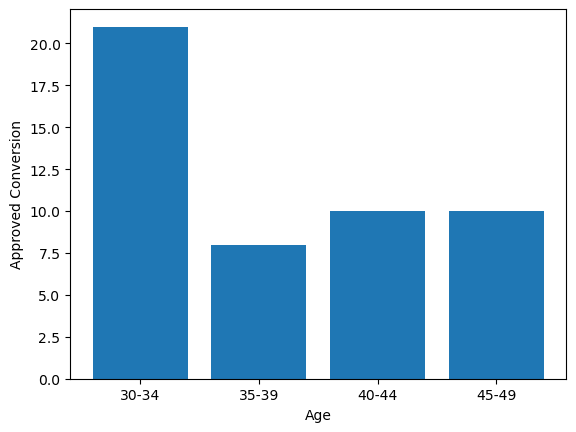

In [32]:
plt.bar(df['age'], df['Approved_Conversion'])
plt.xlabel('Age')
plt.ylabel('Approved Conversion')
plt.show()

# Insights
On the above chart it is clearly showing 30-34 age group dominate on all the analysis

# Gender VS Clicks

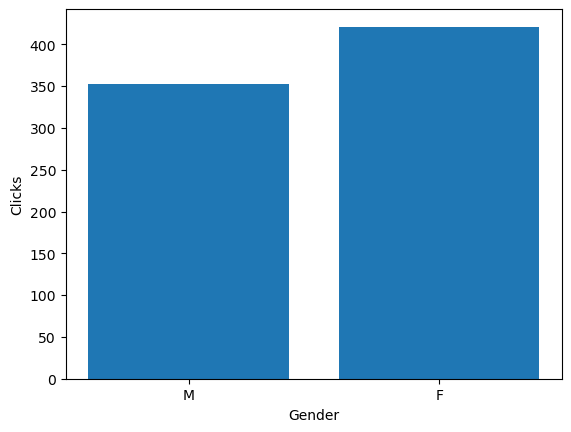

In [33]:
plt.bar(df['gender'], df['clicks'])
plt.xlabel('Gender')
plt.ylabel('Clicks')
plt.show()

# Gender vs Approved conversion

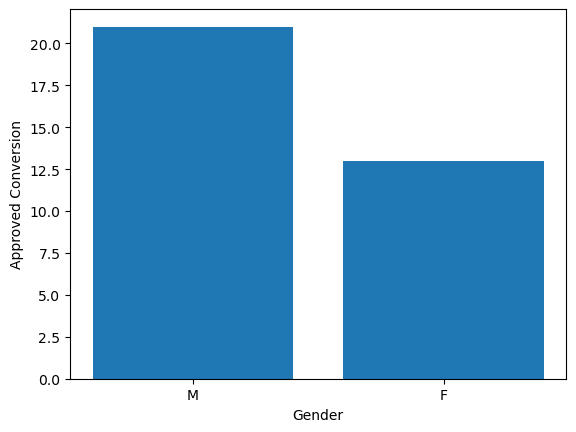

In [34]:
plt.bar(df['gender'], df['Approved_Conversion'])
plt.xlabel('Gender')
plt.ylabel('Approved Conversion')
plt.show()

# Insights 

In the above two charts is showing females click more on the ads but male approved more conversion so male is dominate here

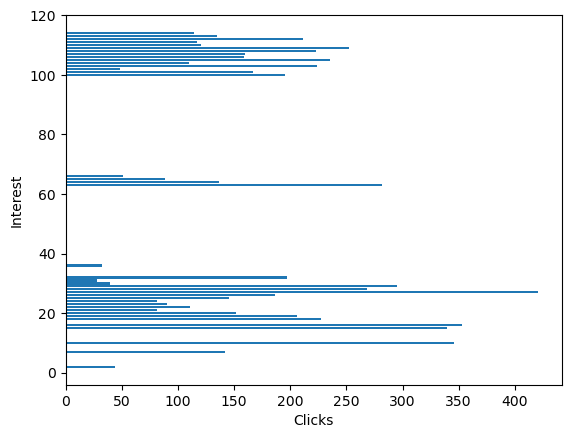

In [35]:
plt.barh(df['interest'], df['clicks'])
plt.xlabel('Clicks')
plt.ylabel('Interest')
plt.show()

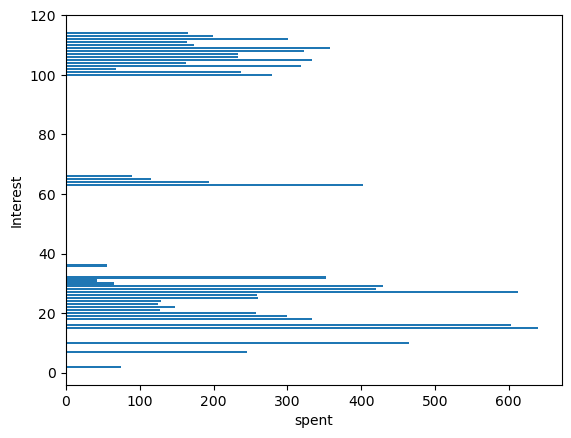

In [36]:
plt.barh(df['interest'], df['spent'])
plt.xlabel('spent')
plt.ylabel('Interest')
plt.show()

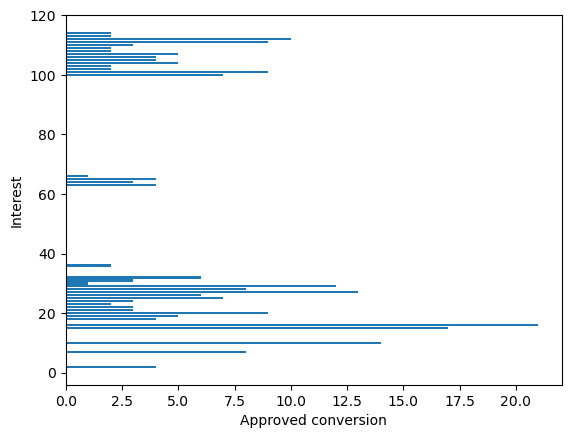

In [37]:
plt.barh(df['interest'], df['Approved_Conversion'])
plt.xlabel('Approved conversion')
plt.ylabel('Interest')
plt.show()

# Insights 

According to Clicks, Spent, Approved conversion between 15 to 30 interest code get more these three\

# Campaign Analysis 

In [38]:
Total_Spend = df.groupby('xyz_campaign_id')['spent'].sum()
Total_Click = df.groupby('xyz_campaign_id')['clicks'].sum()
Total_Approved_Conversion = df.groupby('xyz_campaign_id')['Approved_Conversion'].sum()

In [39]:
print(Total_Spend)
print(Total_Click)
print(Total_Approved_Conversion)

xyz_campaign_id
916       149.710001
936      2893.369999
1178    55662.149959
Name: spent, dtype: float64
xyz_campaign_id
916       113
936      1984
1178    36068
Name: clicks, dtype: int64
xyz_campaign_id
916      24
936     183
1178    872
Name: Approved_Conversion, dtype: int64


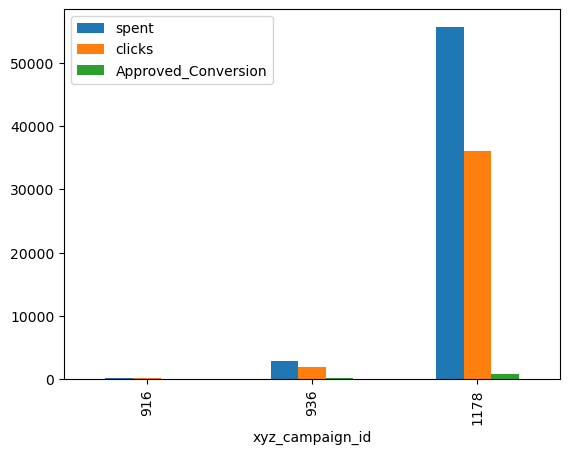

In [40]:
df.groupby('xyz_campaign_id')[['spent', 'clicks', 'Approved_Conversion']].sum().plot(kind='bar')
plt.show()

# Facebook Campaign Analysis

<Axes: xlabel='fb_campaign_id', ylabel='count'>

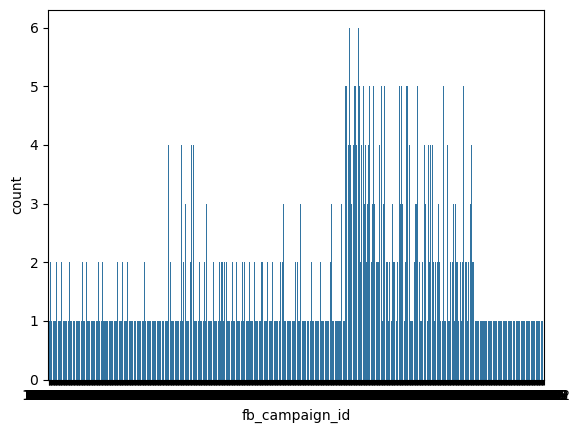

In [41]:
sns.countplot(x='fb_campaign_id', data=df)

# Correlation analysis

In [42]:
df.columns

Index(['ad_id', 'xyz_campaign_id', 'fb_campaign_id', 'age', 'gender',
       'interest', 'impressions', 'clicks', 'spent', 'Total_Conversion',
       'Approved_Conversion'],
      dtype='object')

In [43]:
corr = df.corr(numeric_only=True)

<Axes: >

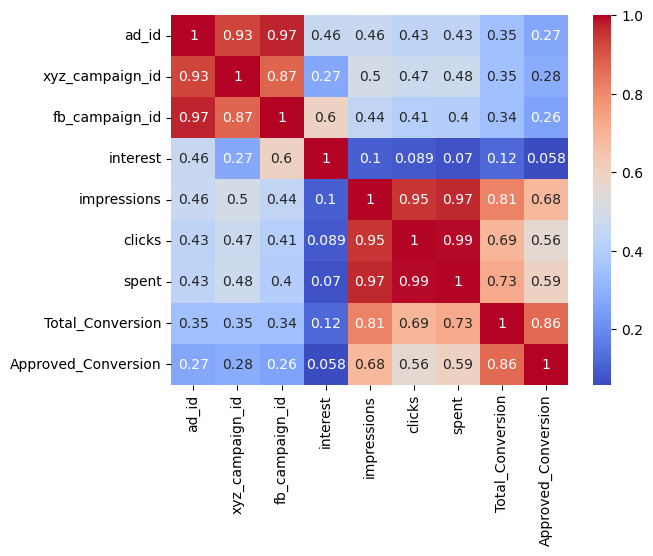

In [44]:
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Insight 
The above 0.90 value these column are very much related between each other

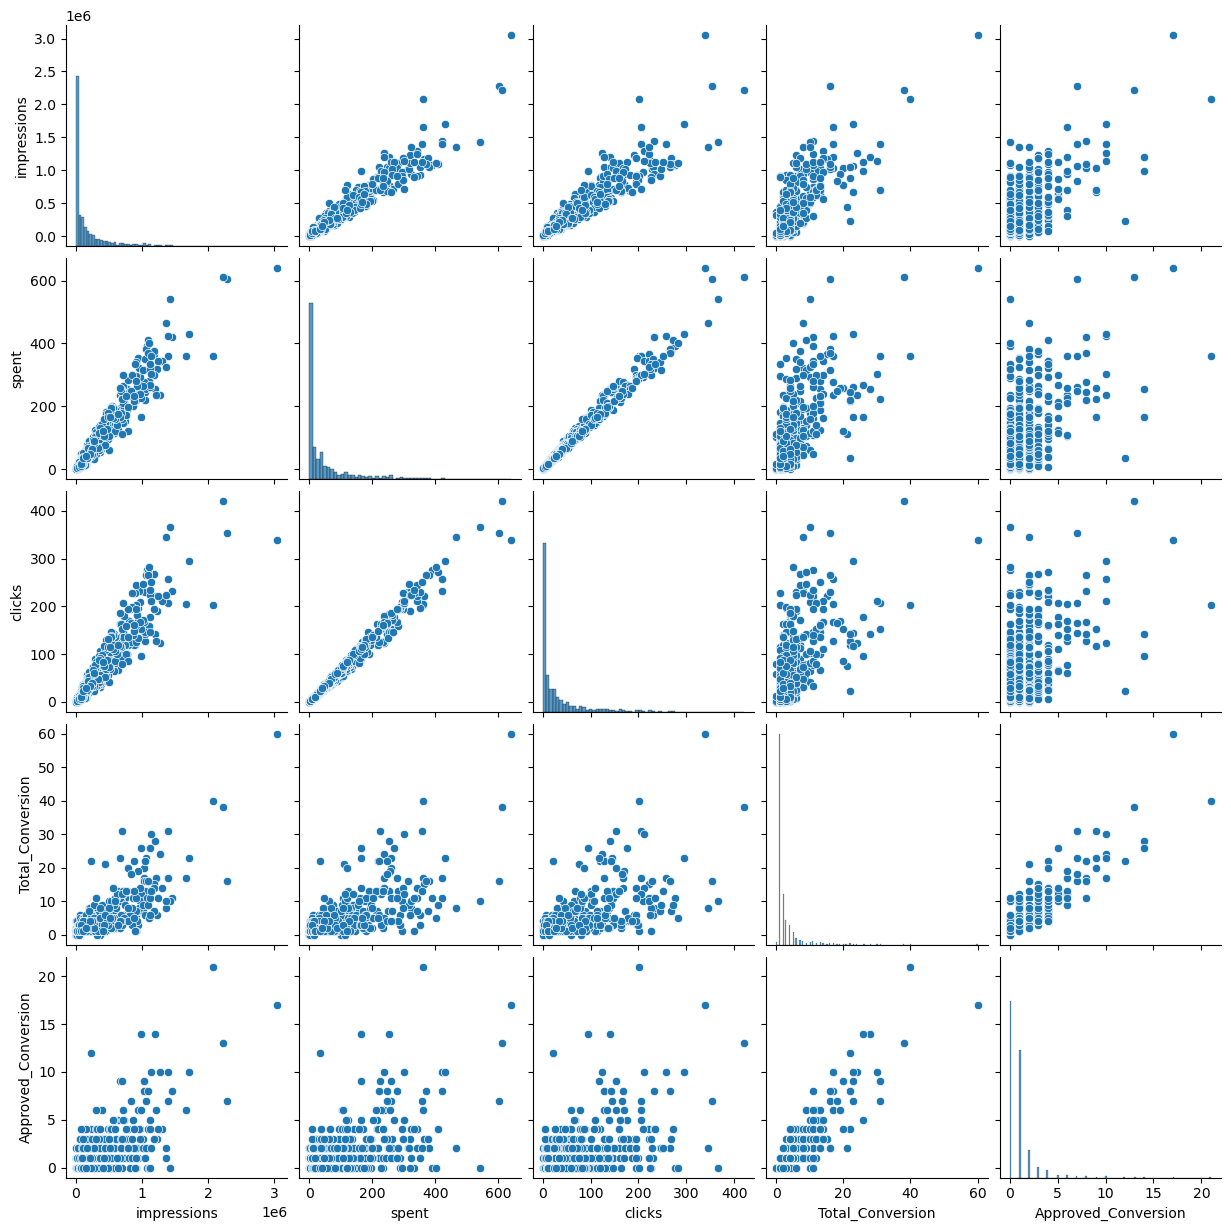

In [45]:
sns.pairplot(df, vars=['impressions', 'spent', 'clicks', 'Total_Conversion', 'Approved_Conversion'])

# Top performing Ads

Top 10 ads by Clicks

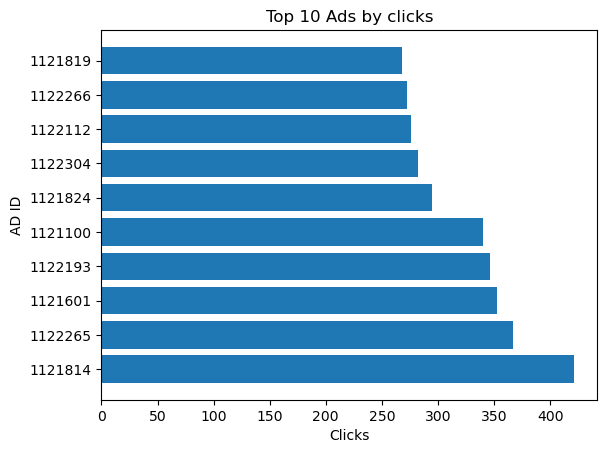

In [46]:
top_clicks = df.nlargest(10, 'clicks')

plt.barh(top_clicks['ad_id'].astype(str), top_clicks['clicks'])
plt.xlabel('Clicks')
plt.ylabel('AD ID')
plt.title('Top 10 Ads by clicks')
plt.show()

Top 10 ads by spend

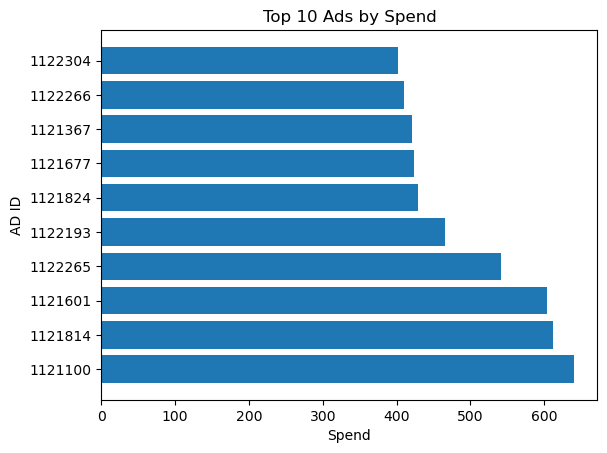

In [47]:
top_spend = df.nlargest(10, 'spent')

plt.barh(top_spend['ad_id'].astype(str), top_spend['spent'])
plt.xlabel('Spend')
plt.ylabel('AD ID')
plt.title('Top 10 Ads by Spend')
plt.show()

Top 10 ads by total conversion

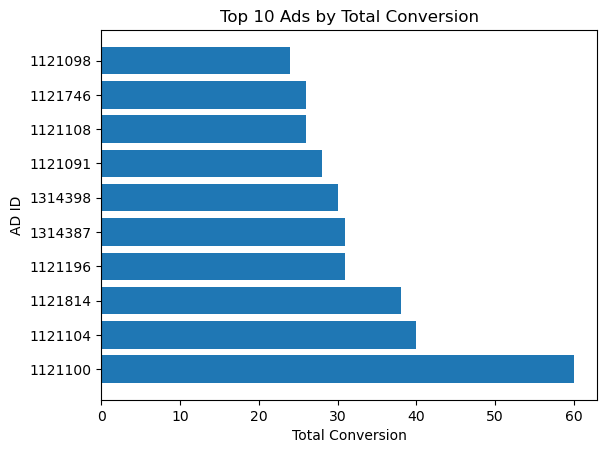

In [48]:
top_total_conversion = df.nlargest(10, 'Total_Conversion')

plt.barh(top_total_conversion['ad_id'].astype(str), top_total_conversion['Total_Conversion'])
plt.xlabel('Total Conversion')
plt.ylabel('AD ID')
plt.title("Top 10 Ads by Total Conversion")
plt.show()

Top 10 Ads by Approved Conversion

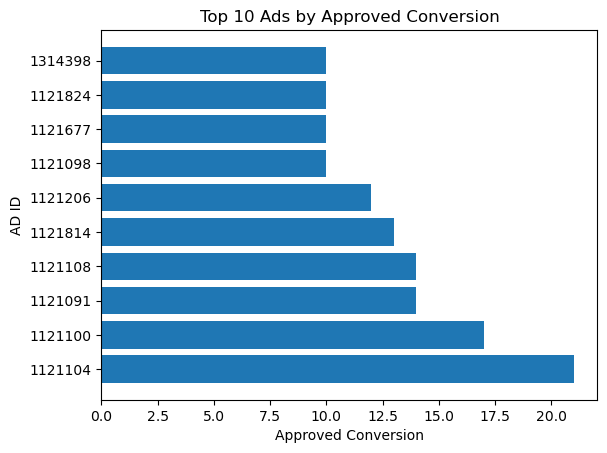

In [49]:
top_approv_conversion = df.nlargest(10, 'Approved_Conversion')

plt.barh(top_approv_conversion['ad_id'].astype(str), top_approv_conversion['Approved_Conversion'])
plt.xlabel('Approved Conversion')
plt.ylabel('AD ID')
plt.title("Top 10 Ads by Approved Conversion")
plt.show()

# Campaign Rankings

Ranking by Spend

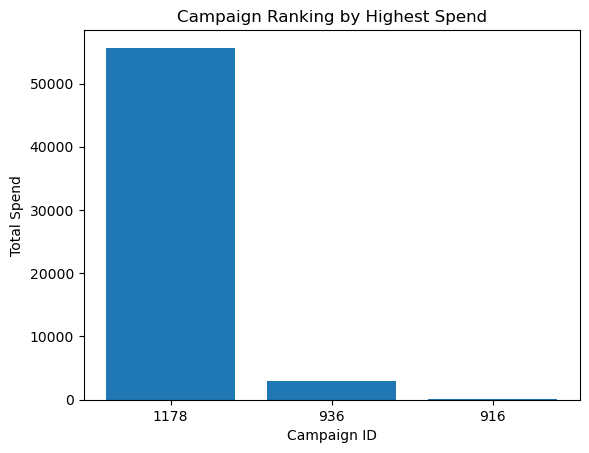

In [50]:
campaign_spend = (
    df.groupby('xyz_campaign_id')['spent']
      .sum()
      .sort_values(ascending=False)
)
plt.bar(campaign_spend.index.astype(str), campaign_spend.values)

plt.title("Campaign Ranking by Highest Spend")
plt.xlabel("Campaign ID")
plt.ylabel("Total Spend")
plt.show()

Ranking by clicks

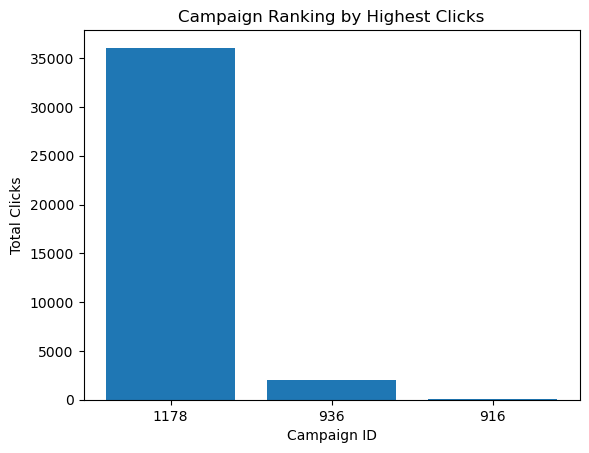

In [51]:
campaign_click = (
    df.groupby('xyz_campaign_id')['clicks'].sum().sort_values(ascending=False)
)

plt.bar(campaign_click.index.astype(str), campaign_click.values)
plt.title("Campaign Ranking by Highest Clicks")
plt.xlabel("Campaign ID")
plt.ylabel("Total Clicks")
plt.show()

Ranking by Approved Conversion

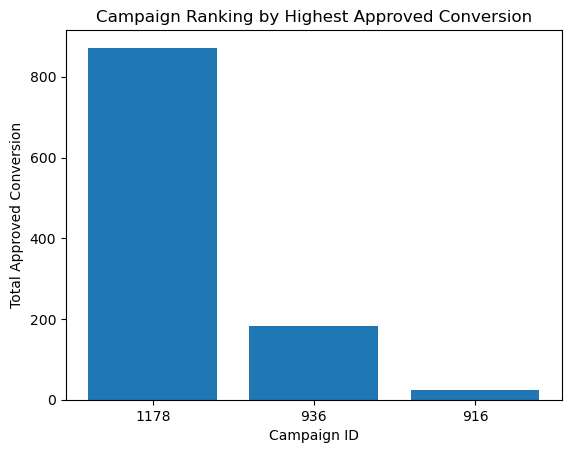

In [52]:
campaign_approved = (
    df.groupby('xyz_campaign_id')['Approved_Conversion'].sum().sort_values(ascending=False)
)

plt.bar(campaign_approved.index.astype(str), campaign_approved.values)
plt.title("Campaign Ranking by Highest Approved Conversion")
plt.xlabel("Campaign ID")
plt.ylabel("Total Approved Conversion")
plt.show()

# Audience Analysis

Best Age group by Clicks

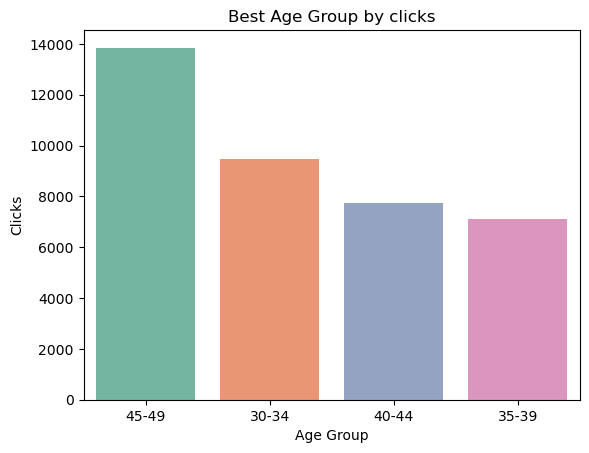

In [53]:
age_click = (
    df.groupby('age')['clicks'].sum().sort_values(ascending=False)
)

sns.barplot(x=age_click.index, y=age_click.values, palette="Set2")
plt.xlabel('Age Group')
plt.ylabel('Clicks')
plt.title('Best Age Group by clicks')
plt.show()

Best Age group by Spend

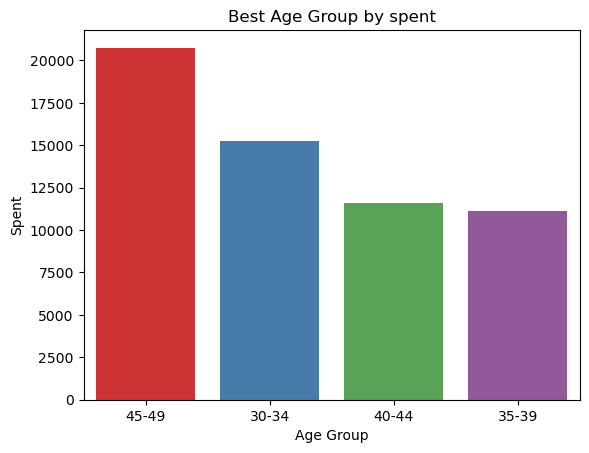

In [54]:
age_spend = (
    df.groupby('age')['spent'].sum().sort_values(ascending=False)
)

sns.barplot(x=age_spend.index, y=age_spend.values, palette='Set1')
plt.xlabel('Age Group')
plt.ylabel('Spent')
plt.title('Best Age Group by spent')
plt.show()

Best Age group by Approved Conversion

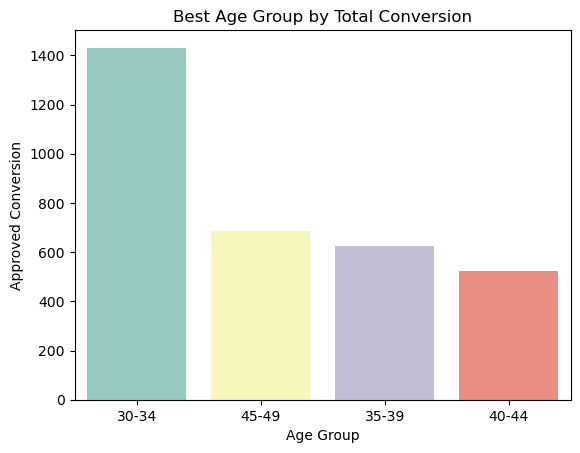

In [55]:
age_total_conversion = (
    df.groupby('age')['Total_Conversion'].sum().sort_values(ascending=False)
)

sns.barplot(x=age_total_conversion.index, y=age_total_conversion.values, palette="Set3")
plt.title("Best Age Group by Total Conversion")
plt.xlabel('Age Group')
plt.ylabel('Approved Conversion')
plt.show()

Best Age group by Approved Conversion

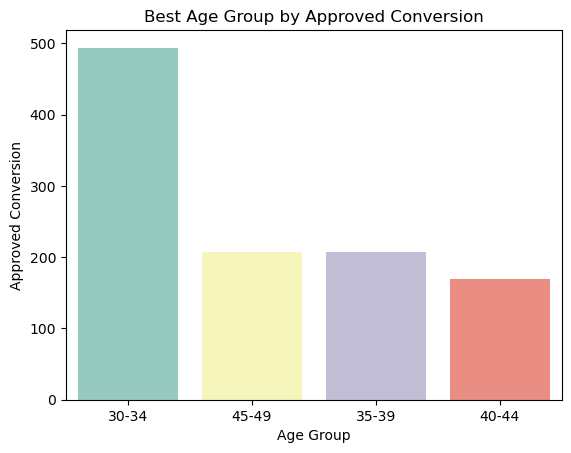

In [56]:
age_approv_conversion = (
    df.groupby('age')['Approved_Conversion'].sum().sort_values(ascending=False)
)

sns.barplot(x=age_approv_conversion.index, y=age_approv_conversion.values, palette="Set3")
plt.title("Best Age Group by Approved Conversion")
plt.xlabel('Age Group')
plt.ylabel('Approved Conversion')
plt.show()

# Gender Conversion and spend
1. Approved Conversion
2. Total Conversion
3. Spent

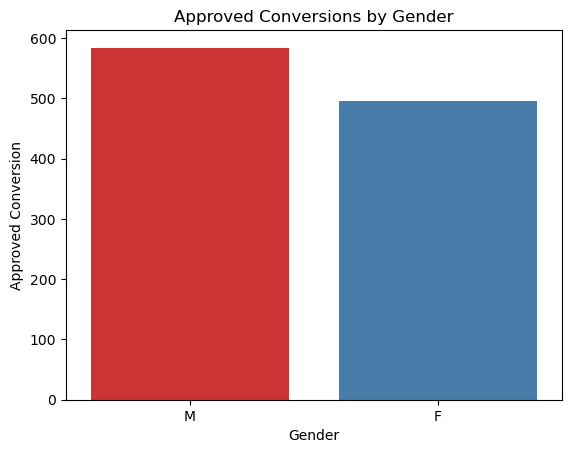

In [66]:
gender_approv_conversion = (
    df.groupby('gender')['Approved_Conversion'].sum().sort_values(ascending=False)
)

sns.barplot(x=gender_approv_conversion.index, y=gender_approv_conversion.values, palette='Set1')
plt.title("Approved Conversions by Gender")
plt.xlabel("Gender")
plt.ylabel("Approved Conversion")
plt.show()

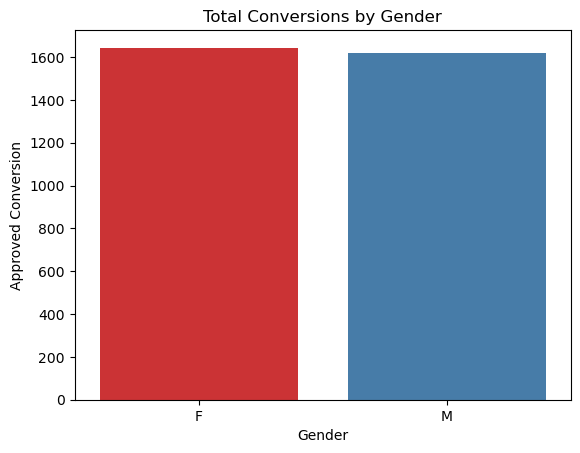

In [67]:
gender_total_conversion = (
    df.groupby('gender')['Total_Conversion'].sum().sort_values(ascending=False)
)

sns.barplot(x=gender_total_conversion.index, y=gender_total_conversion.values, palette='Set1')
plt.title("Total Conversions by Gender")
plt.xlabel("Gender")
plt.ylabel("Approved Conversion")
plt.show()

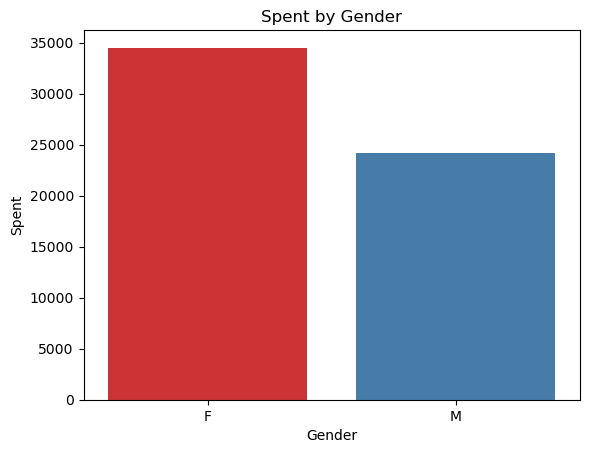

In [68]:
gender_spent = (
    df.groupby('gender')['spent'].sum().sort_values(ascending=False)
)

sns.barplot(x=gender_spent.index, y=gender_spent.values, palette='Set1')
plt.title("Spent by Gender")
plt.xlabel("Gender")
plt.ylabel("Spent")
plt.show()

# Best Interest Category
1. Total Conversion
2. Approved Conversion

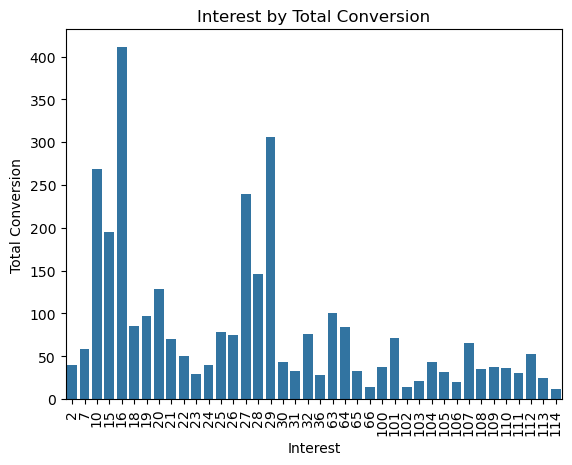

In [ ]:
interest_total_conversion = (
    df.groupby('interest')['Total_Conversion'].sum().sort_values(ascending=False)
)

sns.barplot(x=interest_total_conversion.index, y=interest_total_conversion.values)
plt.title('Interest by Total Conversion')
plt.xlabel('Interest')
plt.ylabel('Total Conversion')
plt.xticks(rotation=90)
plt.show()

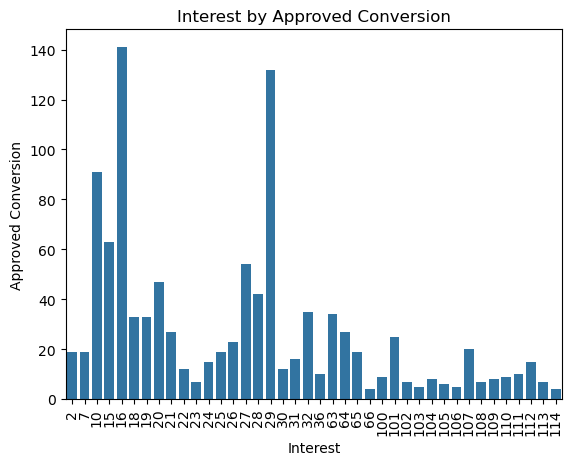

In [60]:
interest_approv_conversion = (
    df.groupby('interest')['Approved_Conversion'].sum().sort_values(ascending=False)
)

sns.barplot(x=interest_approv_conversion.index, y=interest_approv_conversion.values)
plt.xlabel('Interest')
plt.ylabel('Approved Conversion')
plt.xticks(rotation=90)
plt.title('Interest by Approved Conversion')
plt.show()

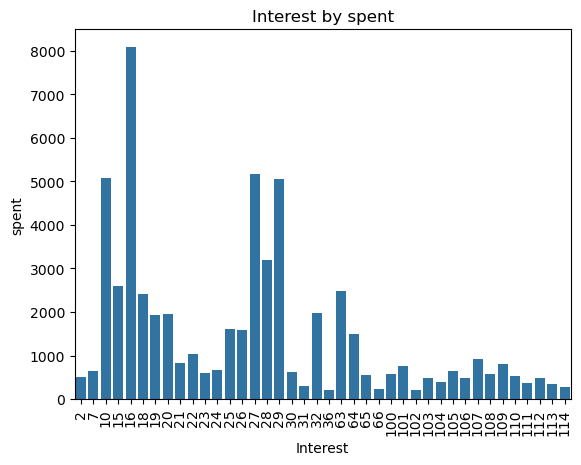

In [69]:
interest_spent = (
    df.groupby('interest')['spent'].sum().sort_values(ascending=False)
)

sns.barplot(x=interest_spent.index, y=interest_spent.values)
plt.title('Interest by spent')
plt.xlabel('Interest')
plt.ylabel('spent')
plt.xticks(rotation=90)
plt.show()

# Multi-variable Analysis

Which gender in which age group perform best

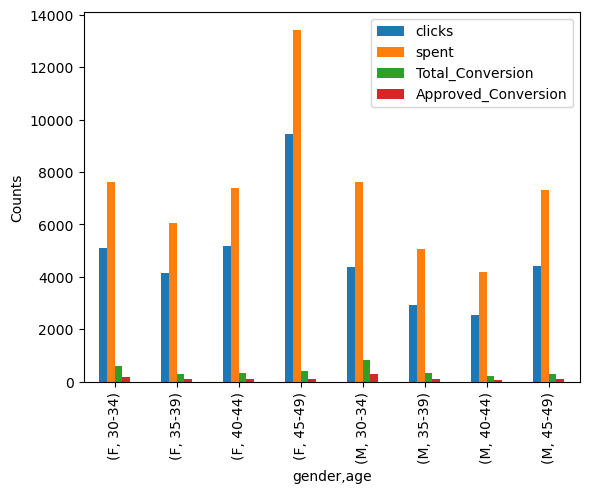

In [61]:
df.groupby(['gender', 'age'])[['clicks', 'spent', 'Total_Conversion', 'Approved_Conversion']].sum().plot(kind='bar')
plt.ylabel('Counts')
plt.show()

# EDA Summary
1. Campaign 1178 generated highest spent.
2. Campaign 1178 had the most clicks.
3. Campaign 1178 generated highest approved conversion
4. Age 45-49 got more click and spend but age 30-34 got more Total conversion and approved coversion
5. Male users Approved Conversion more frequently than female users
6. 16 interest has high spent and conversion